# 定理26・27　動的寂静と「行」— 輪のモデルで見る数値例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。
> **仏教語（無明・行・涅槃）は、原文でも「定理26の数理体系の内部で定義されたモデル相対的・操作的な概念」と断られています。** パーリ語原典の意味そのものではありません。

## 1. 何の例なのか

* **定理26（涅槃寂静）：** 零苦集合 $\mathcal N_\top$ への指数収束。**寂静は静止ではない**（$\mathcal N_\top$ の中で動き続けてよい）。
* **定理27（無明起行定理）：** 「無明に縁りて行が起こる」の一句だけを数学にしたもの（十二縁起の最初の一本の矢印。他の11本は何も主張しない）。

この notebook は、**目標集合が「点」ではなく「輪」** という2次元モデルで、その2つを同時に見ます。

### 定理27の主張（原文の数式解説版）

状態が $\dot x=f_0(x,t)+G(x,t)\,u$（**制御アフィン系**）に従うとします。

* $f_0$：**自然ドリフト**（誰も何もしなくても状態が動く分。川の流れ）。
* $G$：**実アクチュエータ写像**（入力が実際に状態へ効く経路。オールと水の関係）。
* $u_0$：定理26の指定方策が選ぶ入力。$u_{\mathrm{tr}}$：**独立に固定された基準入力**（生命維持・接線運動などの「素の営み」）。
* **志向信号** $\eta_{27}=u_0-u_{\mathrm{tr}}$。
* **条件27-A2：** 基準だけでは高さメーターは変わらない：$\dfrac{\partial W_\top}{\partial t}+\nabla W_\top^{T}F_{\mathrm{tr}}=0$（$F_{\mathrm{tr}}=f_0+Gu_{\mathrm{tr}}$）。

無明（部屋 $\mathcal N_\top$ の外にいること）に対し、

$$
\text{無明}\ \Longrightarrow\ \mathrm{Des}_{27}(t)\ \ge\ \lambda\,W_\top\ \ge\ \lambda c_1\operatorname{dist}(x,\mathcal N_\top)^2\ >0\qquad(27.6)
$$

（**メーター $W_\top$ は止まらずに下がる**。ここまでは定理26だけで言える）。条件27-A のもとでは

$$
\mathrm{Des}_{27}=-\nabla W_\top^{T}G\eta_{27}\ \ge\lambda W_\top,\quad
\text{無明}\Rightarrow -\nabla W_\top^{T}G\eta_{27}>0\ \Rightarrow\ \text{行}\ \wedge\ \eta_{27}\ne0\qquad(27.7)
$$

$$
\|\eta_{27}\|\ \ge\ \frac{\lambda W_\top}{L_{27}}\qquad(\|G^{T}\nabla W_\top\|\le L_{27}\ \text{のとき})\qquad(27.8)
$$

逆に、部屋に入ってしまえば（$x(T)\in\mathcal N_\top(T)$）、$\mathrm{Des}_{27}=0$、$-\nabla W_\top^{T}G\eta_{27}=0$（a.e.）。**ただし零になるのは「無明条件付きの正のアクチュエータ寄与」で、$\eta_{27}$ 自体や生命活動・接線運動が止まるわけではありません**（27.9）。
**行** $\mathrm{Saṅkhārā}_{27}:\Leftrightarrow-\nabla W_\top^{T}G\eta_{27}>0$（27.5）。

### 原文の構造：2段階

① 無明 $\Rightarrow$ メーターが下がる（定理26だけで言える）。② 下降の理由が **本人の漕ぎ** だと言えるには、**条件27-A（基準だけではメーターは変わらない）が追加で要る**。「川の流れに乗っているだけでも舟は進む」ので、流れの分を引き算するのが27-A です。

### 記号とコード変数の対応（このトイ）

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 状態 $x=(r,\theta)$ | $r$：輪（半径 $R_0$）からのずれ、$\theta$：輪の上を回る位相 | `r`, `theta` |
| 目標集合 $\mathcal N_\top$ | $\{r=0\}$＝半径 $R_0=2$ の **輪全体**（点ではない） | `R0 = 2.0` |
| 指定入力 $u_0$ | 半径方向 $-\lambda r$、位相方向 $\omega$ | `r_dot_u0`, `omega` |
| 基準入力 $u_{\mathrm{tr}}$ | 位相方向 $\omega$ のみ（生命維持） | `r_dot_utr = 0.0` |
| 志向信号 $\eta_{27}=u_0-u_{\mathrm{tr}}$ | 半径方向の補正成分 $-\lambda r$ | `eta27_r` |
| 高さメーター $W_\top=\tfrac12r^2$ | 無明残差 $\mathrm{Ign}_{27}$ | `W` |
| 下降率 $\mathrm{Des}_{27}$ | $-dW/dt$ | `des` |
| 行の判定 | $-\nabla W\cdot\eta_{27}>$ 閾値 | `sankhara` |
| $\lambda=1,\ \omega=1.5$ | 半径方向の収束率、輪の上の角速度 | `lam`, `omega` |

このトイでは $G=I$、自然ドリフト $f_0=0$（Python の簡略化）。基準場 $F_{\mathrm{tr}}=(0,\omega)$ で、$\nabla W_\top\cdot F_{\mathrm{tr}}=r\cdot0=0$ なので **条件27-A2 が成り立ちます**。

## 2. なぜこれが「定理26・27の例」と言えるのか

* **寂静の集合が「輪」。** 目標は半径 $R_0=2$ の円周全体です。輪の上の **どこにいても** 苦ゼロ（$r=0$）。だから「1点で静止すること」ではなく、「**動き続けながら輪の上にい続けること**」が寂静になります（原文：寂静は静止ではなく動的）。
* **無明の量が指数減衰。** $\dot r=-\lambda r$ なので $W=\tfrac12r^2=\tfrac12r_0^2e^{-2\lambda t}$（定理26）。
* **行は無明の間だけ。** 志向信号 $\eta_{27}=(-\lambda r,\ 0)$。$r\neq0$（輪の外＝無明）の間は $\eta_{27}\ne0$ で、行が働いています。輪に乗った後は $\eta_{27}=0$ ですが、**位相 $\theta$ は動き続けます**（基準入力 $u_{\mathrm{tr}}$ の分。生命活動）。
* **選んだ引き算。** $\eta_{27}=u_0-u_{\mathrm{tr}}$ で「回転（生命維持）の分」は引かれ、**残るのは「輪へ戻る補正」だけ**。これが「行」の正体です。

## 3. 設定

In [1]:
# %% 準備
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
import numpy as np
import matplotlib.pyplot as plt
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

In [2]:
# %% シミュレーション
R0 = 2.0        # 目標の輪の半径 (N_top)
lam = 1.0       # 半径方向の収束速度 lambda (Lean 側と同じ λ=1)
omega = 1.5     # 輪上の生命活動の角速度 (生きて動き続ける速さ)
dt = 0.01
steps = 1200

def simulate(r0, theta0):
    r, theta = r0, theta0
    rs, thetas, ts = [r], [theta], [0.0]
    Ws, Des = [], []          # Lyapunov無明残差 W_top、その下降率
    eta_norms, sankhara = [], []  # 実アクチュエータ寄与、行の判定
    for i in range(steps):
        W = 0.5 * r**2
        # 制御則: u0 = (半径方向 -lambda*r,  位相方向 omega)
        #        utr = (半径方向 0,          位相方向 omega)  <- 基準(生命維持のみ)
        r_dot_u0 = -lam * r
        r_dot_utr = 0.0
        eta27_r = r_dot_u0 - r_dot_utr   # 半径方向の「行」成分

        # 実際のダイナミクス(u0を採用)
        r_new = r + dt * r_dot_u0
        theta_new = theta + dt * omega

        W_new = 0.5 * r_new**2
        des = -(W_new - W) / dt   # 残差下降率 Des27 ≈ -dW/dt

        Ws.append(W_new)
        Des.append(des)
        eta_norms.append(abs(eta27_r))
        # Sankhara27: -grad(W)^T * G * eta27 > 0 かどうか。1次元なので grad(W)=r
        # (数値誤差対策として、実効的にゼロとみなす閾値 tol を設ける)
        tol = 2 * lam * 1e-6   # 無明判定 W_top>1e-6 と同じ閾値 (-r*eta27 = lam*r^2 = 2*lam*W_top)
        sankhara.append(1 if (-r * eta27_r) > tol else 0)

        r, theta = r_new, theta_new
        rs.append(r); thetas.append(theta); ts.append((i + 1) * dt)

    return (np.array(ts), np.array(rs), np.array(thetas),
            np.array(Ws), np.array(Des), np.array(eta_norms), np.array(sankhara))

ts, rs, thetas, Ws, Des, etas, sankhara = simulate(r0=3.0, theta0=0.0)

`simulate(r0, theta0)` は $dt=0.01$、1200 ステップ（時間 12）のオイラー法です。各ステップで、無明残差 $W$、下降率 $\mathrm{Des}_{27}$、志向信号 $\eta_{27}$（半径成分）、行の判定（$-r\,\eta_{27}$ が閾値 $2\lambda\cdot10^{-6}$ を超えるか）を記録します。出発は $r_0=3,\ \theta_0=0$（輪から外側に $3$、つまり半径 $5$ の位置）。

## 4. 図を読む

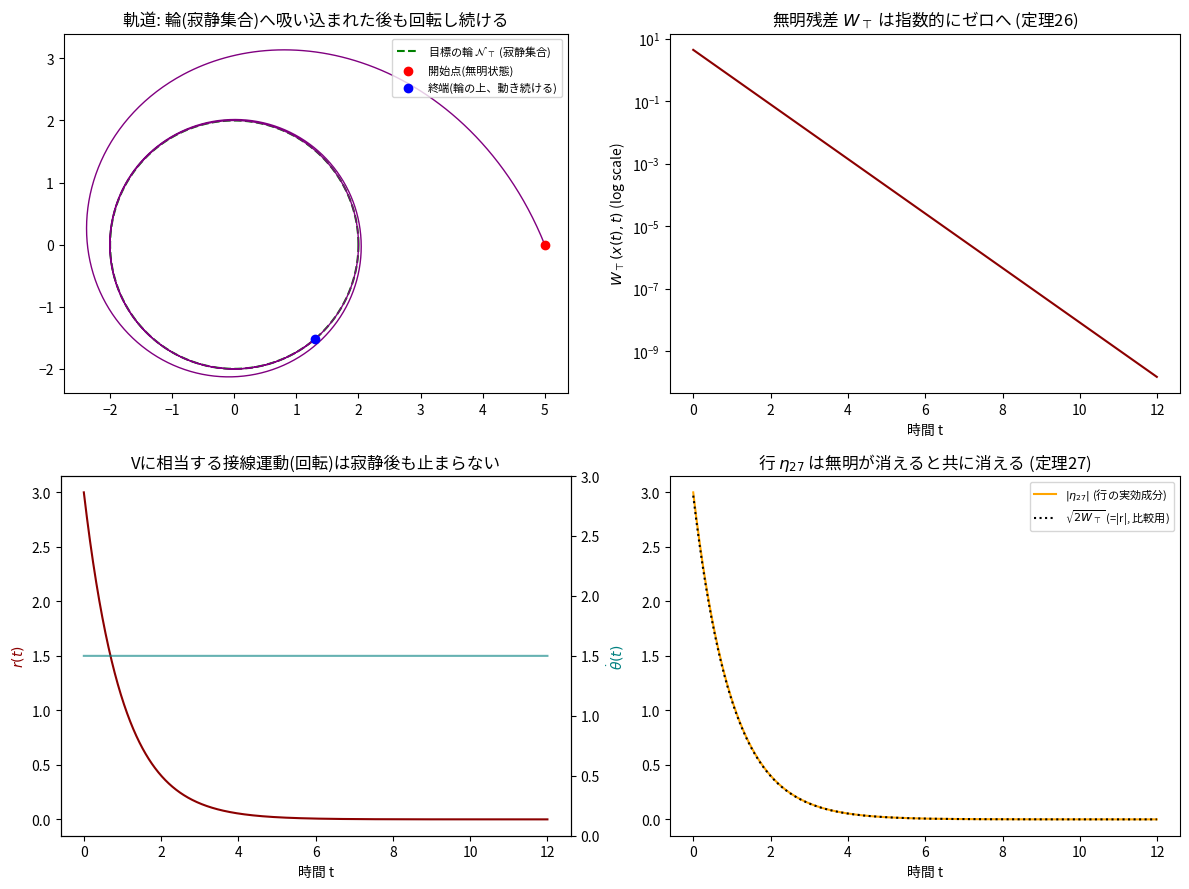

In [3]:
# %% 可視化
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (1) 実際の軌道: xy平面上で輪に吸い込まれつつ回転し続ける
# 実座標: 「輪からの距離r」を輪の法線方向のオフセットとして描く(半径 R0+r)
Xc = (R0 + (rs[:-1])) * np.cos(thetas[:-1])
Yc = (R0 + (rs[:-1])) * np.sin(thetas[:-1])
circle_th = np.linspace(0, 2 * np.pi, 200)
axes[0, 0].plot(R0 * np.cos(circle_th), R0 * np.sin(circle_th), "g--", label=r"目標の輪 $\mathcal{N}_\top$ (寂静集合)")
axes[0, 0].plot(Xc, Yc, color="purple", lw=1)
axes[0, 0].scatter([Xc[0]], [Yc[0]], color="red", zorder=5, label="開始点(無明状態)")
axes[0, 0].scatter([Xc[-1]], [Yc[-1]], color="blue", zorder=5, label="終端(輪の上、動き続ける)")
axes[0, 0].set_aspect("equal")
axes[0, 0].set_title("軌道: 輪(寂静集合)へ吸い込まれた後も回転し続ける")
axes[0, 0].legend(fontsize=8, loc="upper right")

# (2) Lyapunov残差 W_top(x,t) の指数減衰
axes[0, 1].semilogy(ts[:-1], Ws, color="darkred")
axes[0, 1].set_xlabel("時間 t")
axes[0, 1].set_ylabel(r"$W_\top(x(t),t)$ (log scale)")
axes[0, 1].set_title("無明残差 $W_\\top$ は指数的にゼロへ (定理26)")

# (3) 半径 r と 位相角速度(=生命活動)の比較: rはゼロに収束するがthetaは回り続ける
axes[1, 0].plot(ts, rs, color="darkred", label=r"$r(t)$ (輪からのズレ、$\to 0$)")
ax2 = axes[1, 0].twinx()
theta_dot_num = np.gradient(thetas, ts)
ax2.plot(ts, theta_dot_num, color="teal", alpha=0.6, label=r"$\dot\theta(t)$ (輪上の角速度、一定のまま)")
ax2.set_ylim(0, 3)   # 数値微分の丸め誤差(1e-13)が拡大表示されないよう固定
axes[1, 0].set_xlabel("時間 t")
axes[1, 0].set_ylabel(r"$r(t)$", color="darkred")
ax2.set_ylabel(r"$\dot\theta(t)$", color="teal")
axes[1, 0].set_title("Vに相当する接線運動(回転)は寂静後も止まらない")

# (4) eta27(実アクチュエータの行成分)は無明残差が消えると共にゼロへ
axes[1, 1].plot(ts[:-1], etas, color="orange", label=r"$|\eta_{27}|$ (行の実効成分)")
axes[1, 1].plot(ts[:-1], np.sqrt(2 * Ws) , color="black", ls=":", label=r"$\sqrt{2 W_\top}$ (=|r|, 比較用)")
axes[1, 1].set_xlabel("時間 t")
axes[1, 1].set_title(r"行 $\eta_{27}$ は無明が消えると共に消える (定理27)")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 左上：軌道（平面）

緑の破線が目標の輪 $\mathcal N_\top$（半径 $2$）。赤い点が開始点（半径 $5$、右端 $(5,0)$）、青い点が終端。紫の線が軌道。
**外側から渦を巻きながら輪へ近づき、最後は輪の上を回っています。** 輪の外側から一度大きく回り込み、輪の線に **ぴったり重なって** 1周以上回り続けます。終端の青い点は輪の上にあり、止まっているのではなく **位相が回り続けた先** です（12 秒で約 $18$ ラジアン $\approx$ 2.9 周）。
→ 「**輪に着いても止まらない**」＝動的寂静。

### 右上：無明残差 $W_\top$（縦軸は対数）

**1本の直線**。$t=0$ の約 $4.5$ から $t=12$ の約 $10^{-10}$ まで、傾き $-2\lambda=-2$。**指数減衰** です。$W=\tfrac12r_0^2e^{-2\lambda t}=4.5\,e^{-2t}$ と合っています（定理26）。

### 左下：$r(t)$ と角速度 $\dot\theta(t)$

* **赤茶（$r$、左軸）：** $3$ から指数的に $0$ へ。約 6 秒で見分けがつかないほど小さくなります。
* **青緑（$\dot\theta$、右軸）：** **ずっと $1.5$ の水平線**。$r\to0$ になっても **角速度は変わりません**。
  輪に着いた（$r=0$）後も、輪の上を一定の速さで回り続ける。これが「寂静は静止ではない」の中身です。

### 右下：行の実効成分 $|\eta_{27}|$

橙の線と黒い点線（$\sqrt{2W_\top}=|r|$）が **完全に重なって** います。$|\eta_{27}|=\lambda|r|$（$\lambda=1$）で、無明の量 $r$ とともに指数的に $0$ へ。**無明が消えれば行も消えます**（(27.9) の「無明条件付きの正のアクチュエータ寄与は零」の対応物）。
**注意：** このトイでは、行 $-r\,\eta_{27}=\lambda r^2$ も無明の量 $W=\tfrac12r^2$ も、同じ $r$ の関数です。だから「無明 $\Leftrightarrow$ 行」が成り立つのは、この例では **ほぼ恒等式** で、独立な検証にはなっていません。**この同値が非自明な内容をもつのは、一般の $f_0,G$ をもつ系**（定理27）で、そこは Lean の一般定理で証明しました（下記）。

## 5. 数値確認：行は無明の間だけ

In [4]:
# %% 数値での確認: 行(sankhara)が無明の間(W_top>1e-6)だけ1であること
W_before = 0.5 * rs[:-1]**2        # sankhara[i] は更新前の状態 r_i で判定している
transition_idx = int(np.argmax(W_before < 1e-6))
print(f"W_top < 1e-6 に到達した最初のステップ: {transition_idx} / {steps}")
print(f"それ以前でSankhara27=1の割合: {sankhara[:transition_idx].mean():.3f}")
print(f"それ以後でSankhara27=1の割合: {sankhara[transition_idx:].mean():.3f}")
assert 0 < transition_idx < steps
assert sankhara[:transition_idx].all() and not sankhara[transition_idx:].any()   # 無明 ⇔ 行 (27.10)
assert np.all(np.diff(thetas) > 0)                                               # 位相は回り続ける(動的寂静)

W_top < 1e-6 に到達した最初のステップ: 763 / 1200
それ以前でSankhara27=1の割合: 1.000
それ以後でSankhara27=1の割合: 0.000


* $W_\top<10^{-6}$ になる最初のステップは $763/1200$。
* それ以前は行の判定が **100%**（無明の間は行が働く）、それ以後は **0%**（輪に乗った後は行が消える）。
* `assert`：(i) 行は無明の間だけ成り立つ（(27.10) の同値のこのトイでの確認）、(ii) 位相は単調に増え続ける（動的寂静）。

（判定の閾値 $10^{-6}$ は **$W_\top$ の値そのもの** に対する閾値で、ステップ数を数えて打ち切っているのではありません。）

## 6. Lean が扱う割引コストの確認

In [5]:
# %% Lean が扱うコスト V⊤=3r², ρ=1 のもとで J*(r0)=r0² を数値積分で確認
tt = np.linspace(0, 30, 300001)
J = np.trapezoid(np.exp(-tt) * 3 * (3.0 * np.exp(-lam * tt))**2, tt)
print("J*(r0=3) =", J, " (理論値 r0^2 = 9)")
assert abs(J - 9.0) < 1e-3

J*(r0=3) = 9.0000000675  (理論値 r0^2 = 9)


Lean の輪モデルは、走行コスト $V_\top=3r^2$（位相に依らない）、割引 $\rho=1$。このとき $J^*(r_0)=\int_0^\infty e^{-t}\,3\,(r_0e^{-t})^2dt=\dfrac{3r_0^2}{3}=r_0^2$。$r_0=3$ で **$9$**。数値積分は $9.0000000675$ で理論値 $9$ と一致します。

## 7. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「無明に縁りて行が起こる」＝まだ寂静に達していないなら、必ず何かを漕いでいる。** 原文の最短の言い換えです。右下の橙の線がそれです。部屋（輪）の外にいる間は、志向信号（漕ぎ）が働き、輪に着けば消える。
* **「無明」は気分や頭の悪さではなく、位置の事実。** 原文：「いま自分がいる場所が、苦がゼロになる集合の外側だという、位置についての事実」。ここでは「輪の外にいる（$r\neq0$）」にあたります。
* **寂静は静止ではない（動的寂静）。** 原文は、ゼロになるのは **部屋の外へ出ようとする向きの成分だけ** で、「生きること・考えること・他者に応えることが止まるわけではない」と述べます。左下の水平線 $\dot\theta=1.5$ と、左上の「輪に着いても回り続ける」軌道がその絵です。
* **なぜ「輪」にしたのか（解釈）。** 目標が1点だと、着いた瞬間に動きも止まってしまい、「寂静＝静止」と誤読されます。目標を **輪** にすれば、「苦がゼロの状態の中を動き続けられる」ことを視覚的に示せます。原文も「𝒩⊤(t) と書いて $t$ が付いているのは、寂静が凍りついた一点ではなく動きうる安全地帯だから」と説明しています。
* **このトイでは $V_\top$ も $0$ になる。** Lean の輪モデルの走行コストは $V_\top=3r^2$ で、輪の上では **$V_\top$ 自体も $0$** です。したがって、**この例は「$V$ はゼロにならず $J^*$ だけがゼロになる」という原文の読み（涅槃で消えるのは評価関数 $V$ ではなく残りの苦の合計 $J^*$）を直接は示していません**。この例が示しているのは、**半径方向の苦（無明残差）が指数的に消える一方で、輪の上の運動（位相）は続く** ということです。
* 原文は、**パーリ語原典の「行」** （身体的・言語的・心的な三種）を、この一本の内積に還元するものではない、と断っています。

## 8. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem26_RingModel.lean`（定理26の全条件と結論）、`Theorem27_Operational.lean`（定理27の一般定理の適用）、`Theorem26_27_ControlClasses.lean`（制御クラスの拡張）、`Theorem27_AvijjaSankhara.lean`（27-A の代数核と、2 次元ベクトル入力での接続）。

| | 内容 | 状態 |
| --- | --- | --- |
| 定理26（輪モデル） | 状態 $(r,\varphi)$、$\dot r=-r$、$\dot\varphi=\tfrac32$、走行コスト $V_\top=3r^2$、$\rho=1$。$\mathcal N_\top=\{r=0\}$（輪）、$J^*=r^2$、$W=r^2$（$c_1=c_2=1$、$\lambda_W=2$）。一般定理から **零苦集合への所属、$W$ と距離の指数減衰、$J^*\to0$、動的寂静（輪の上に留まり位相は動き続ける）** | 証明済 |
| 定理27（一般定理の適用） | $E_2=\mathbb R^2$ 上で、実アクチュエータ $G=\mathrm{id}$、自然ドリフト、指定入力 $u_0=(-\kappa r,\omega)$、基準入力 $u_{\mathrm{tr}}=(\mu r,\omega)$（27-A2 成立）を構成し、**一般定理を適用**：無明（輪の外）$\Leftrightarrow$ 下降率 $>0$ $\Leftrightarrow$ 行 $-\langle\nabla W,G(u_0-u_{\mathrm{tr}})\rangle>0$（a.e.）。$r_0\ne0$ で無明が全時刻に起き、行の寄与が正（非空虚） | 証明済 |
| **制御クラスの拡張**（線形ゲイン族） | 許容方策を、ゲイン $0\le k(t)\le\tfrac12$ の**定数・連続・有界可測**な線形フィードバック $u(t,r)=-k(t)r$ に広げる。連続ゲインでは ODE を全時刻で、有界可測ゲインでは a.e. で満たし、再始動できる。**最大ゲインが費用最小**（価値 $r_0^2$。拡張実数費用で比較するので候補の可積分性を仮定しない）。24・26 のデータ構造の全フィールドを満たし、永久苦痛ゼロ（PZS）は $x=0$ と同値、その目標は輪に一致し、非 PZS なら 27 の作動量が a.e. 正 | 証明済 |
| 限界の例 | 非負ゲインを無制限に許すと費用の下限は $0$ だが**達成されない**（非零初期値）。Borel フィードバック $b(x)=1\ (x\ne0),\ b(0)=0$ は 0 から出る**2 つの異なる前向き解**（静止と $x(t)=t$）を許す（Borel 可測性だけでは解が一意でない） | 証明済 |
| Euler 離散化、閾値 $10^{-6}$ による判定、図の軌道 | 数値のみ | 未証明 |

* 方策のクラスは**線形ゲイン族**に限っています。**任意の Borel フィードバックの閉ループ解の存在・一意性は主張しません**（上の限界の例のとおり、成立条件の指定が必要です）。
* Lean の $\mu=\kappa=\tfrac12$（このとき $f_0+Gu_0=(-r,\omega)$ で Python の動きと一致）、Python は簡略化して $f_0=0$、$u_0=(-\lambda r,\omega)$ としています。$\eta_{27}=u_0-u_{\mathrm{tr}}=(-r,0)$ は両者で同じです。
* メーターの尺度は Python が $W=\tfrac12r^2$、Lean が $W=r^2$ です。原文の注意の通り、$\mathrm{Ign}_{27}$ の絶対値に意味はなく、意味を持つのは「ゼロか正か」と「減っているか」です。